<a href="https://colab.research.google.com/github/sazzeb/Statistical-learning-method-4/blob/main/CSCE5215_LDL_Tennis_Fixed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Large Margin Weighted k-Nearest Neighbors LDL Applied to ATP Tennis (2024)

**Paper:** Wang & Geng, *Large Margin Weighted k-Nearest Neighbors Label Distribution Learning for Classification*, IEEE TNNLS, Vol. 35, No. 11, Nov. 2024.

**Dataset:** ATP 2024 match statistics — Jeff Sackmann ([github.com/JeffSackmann/tennis_atp](https://github.com/JeffSackmann/tennis_atp))

---
## Bug Fixes Applied (vs. original Colab)
| # | Location | Bug | Fix |
|---|----------|-----|-----|
| 1 | `wknn_ldl_train` | Fixed step `0.01/(t+1)` caused gradient divergence — WkNN loss exploded to ~35% ± 42% | After each gradient step, **project onto the non-negative simplex**: clip negatives, L1-normalize |
| 2 | `ldknn_ldl_predict` | Training-set distances were accidentally passed and used for test instances | Predict now **always computes test distances** internally via `find_knn(X_train, X_test, k)` |
| 3 | `evaluate` | Error probability used `D_true[predicted_label]` → pinned all methods near 60% | Corrected to `1 − D_pred[predicted_label]` per Wang & Geng (2024) definition |

---
## Notebook Structure
1. Install & Import Libraries
2. Load & Clean Dataset
3. Feature Engineering
4. Label Distribution Construction (Gaussian Kernel)
5. Algorithm Implementations (AA-kNN, SA-BFGS, WkNN-LDL, LWkNN-LDL, LDkNN-LDL)
6. Experiments & Evaluation
7. Results Tables
8. Visualisations
9. Qualitative Examples

> **CSCE 5215 — Machine Learning Project**

## Cell 1 — Install Libraries

In [2]:
# ── Install any libraries not already in Colab ──────────────────────────────
!pip install -q pandas numpy scikit-learn scipy matplotlib seaborn


## Cell 2 — Import Libraries

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import BallTree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from scipy.optimize import line_search
warnings.filterwarnings('ignore')
np.random.seed(42)

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
})

LABEL_NAMES = ['Dominant', 'Strong', 'Average', 'Struggling', 'Poor']
COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']
print(f'All libraries loaded successfully. {COLORS}')


All libraries loaded successfully. ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']


## Cell 3 — Upload & Load the Dataset

> **Instructions:** Run this cell, then click **Choose Files** and upload `atp_matches_2024.csv`.
> You can download the file from: https://github.com/JeffSackmann/tennis_atp


In [8]:
from google.colab import files
print('Please upload atp_matches_2024.csv')
uploaded = files.upload()

import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))
print(f'Loaded {len(df_raw):,} rows and {df_raw.shape[1]} columns.')
df_raw.head(3)


Please upload atp_matches_2024.csv


Saving 2024.csv to 2024 (1).csv
Loaded 3,076 rows and 50 columns.


,tourney_id,tourney_name,surface,draw_size,tourney_level,indoor,tourney_date,match_num,winner_id,winner_seed,...,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced
0,2024-339,Brisbane,Hard,32,250,O,20240101,1,D875,2.0,...,5.0,4.0,0.0,86.0,51.0,32.0,21.0,15.0,4.0,8.0
1,2024-339,Brisbane,Hard,32,250,O,20240101,2,AE14,NaN,...,0.0,3.0,2.0,83.0,46.0,38.0,22.0,12.0,2.0,2.0
2,2024-339,Brisbane,Hard,32,250,O,20240101,3,H0BH,NaN,...,2.0,16.0,1.0,62.0,47.0,36.0,6.0,10.0,2.0,4.0


## Cell 4 — Data Cleaning & Overview

In [10]:
# ── Define the stat columns we need ─────────────────────────────────────────
STAT_COLS = [
    'w_ace','w_df','w_svpt','w_1stIn','w_1stWon','w_2ndWon','w_bpSaved','w_bpFaced',
    'l_ace','l_df','l_svpt','l_1stIn','l_1stWon','l_2ndWon','l_bpSaved','l_bpFaced'
]
print('Missing values in key stat columns before cleaning:')
print(df_raw[STAT_COLS].isnull().sum().to_string())

# Drop rows with any missing stat
df = df_raw.dropna(subset=STAT_COLS).copy()
df = df.reset_index(drop=True)
print(f'\nRows before cleaning : {len(df_raw):,}')
print(f'Rows after cleaning  : {len(df):,}')
print(f'Rows dropped         : {len(df_raw) - len(df):,}')
print('\nDataset overview:')
print(f"  Surfaces : {df['surface'].value_counts().to_dict()}")
print(f"  Levels   : {df['tourney_level'].value_counts().to_dict()}")
print(f"  Rounds   : {df['round'].value_counts().to_dict()}")
print(f"  Avg match duration: {df['minutes'].mean():.1f} min")
print(f"  Date range: {df['tourney_date'].min()} to {df['tourney_date'].max()}")


Missing values in key stat columns before cleaning:
w_ace        61
w_df         61
w_svpt       61
w_1stIn      61
w_1stWon     61
w_2ndWon     61
w_bpSaved    61
w_bpFaced    61
l_ace        61
l_df         61
l_svpt       61
l_1stIn      61
l_1stWon     61
l_2ndWon     61
l_bpSaved    61
l_bpFaced    61

Rows before cleaning : 3,076
Rows after cleaning  : 3,015
Rows dropped         : 61

Dataset overview:
  Surfaces : {'Hard': 1727, 'Clay': 964, 'Grass': 324}
  Levels   : {'250': 986, 'M': 691, 'G': 505, '500': 432, 'D': 222, 'A': 103, 'O': 61, 'F': 15}
  Rounds   : {'R32': 893, 'R16': 509, 'R64': 463, 'R128': 416, 'RR': 273, 'QF': 256, 'SF': 136, 'F': 68, 'BR': 1}
  Avg match duration: 115.8 min
  Date range: 20240101 to 20241218


## Cell 5 — Feature Engineering

Each match produces **two** player-level instances (winner + loser).
We compute **6 normalised serve-performance features** per player:

| Feature | Formula |
|---------|--------|
| First serve % | 1stIn / svpt |
| First serve win rate | 1stWon / 1stIn |
| Second serve win rate | 2ndWon / (svpt - 1stIn) |
| Break point save rate | bpSaved / bpFaced |
| Ace rate | ace / svpt |
| Double fault rate | df / svpt |


In [12]:
def extract_features(row, prefix):
    """Extract 6 serve-quality features for one player in one match."""
    svpt     = row[f'{prefix}_svpt']
    first_in = row[f'{prefix}_1stIn']
    second   = max(svpt - first_in, 1e-6)   # avoid division by zero
    f1 = first_in / svpt         if svpt     > 0 else 0.0
    f2 = row[f'{prefix}_1stWon'] / first_in  if first_in > 0 else 0.0
    f3 = row[f'{prefix}_2ndWon'] / second
    bpf = row[f'{prefix}_bpFaced']
    f4 = row[f'{prefix}_bpSaved'] / bpf      if bpf  > 0 else 1.0
    f5 = row[f'{prefix}_ace']    / svpt       if svpt > 0 else 0.0
    f6 = row[f'{prefix}_df']     / svpt       if svpt > 0 else 0.0
    return [f1, f2, f3, f4, f5, f6]

# Build feature matrix: winners first, then losers
X_winner = np.array([extract_features(row, 'w') for _, row in df.iterrows()])
X_loser  = np.array([extract_features(row, 'l') for _, row in df.iterrows()])
X_raw    = np.vstack([X_winner, X_loser])

# Track player names and match info for qualitative analysis later
player_names   = list(df['winner_name']) + list(df['loser_name'])
opponent_names = list(df['loser_name'])  + list(df['winner_name'])
surfaces       = list(df['surface'])     + list(df['surface'])
tournaments    = list(df['tourney_name'])+ list(df['tourney_name'])
is_winner      = [True]*len(df) + [False]*len(df)

FEATURE_NAMES = [
    '1st Serve %', '1st Serve Win Rate', '2nd Serve Win Rate',
    'BP Save Rate', 'Ace Rate', 'Double Fault Rate'
]
print(f'Feature matrix shape : {X_raw.shape}  ({X_raw.shape[0]:,} instances x {X_raw.shape[1]} features)')
print()
stats_df = pd.DataFrame(X_raw, columns=FEATURE_NAMES)
print('Feature statistics:')
print(stats_df.describe().round(3).to_string())


Feature matrix shape : (6030, 6)  (6,030 instances x 6 features)

Feature statistics:
       1st Serve %  1st Serve Win Rate  2nd Serve Win Rate  BP Save Rate  Ace Rate  Double Fault Rate
count     6030.000            6030.000            6030.000      6030.000  6030.000           6030.000
mean         0.627               0.719               0.514         0.615     0.080              0.034
std          0.079               0.099               0.122         0.260     0.059              0.027
min          0.356               0.000               0.000         0.000     0.000              0.000
25%          0.574               0.656               0.438         0.500     0.036              0.015
50%          0.629               0.724               0.515         0.625     0.069              0.029
75%          0.679               0.786               0.588         0.778     0.112              0.048
max          1.000               1.000               1.615         1.000     0.444              0.

## Cell 6 — Label Distribution Construction

Since the dataset has no pre-made label distributions, we build them using a **Gaussian kernel** — the standard approach in LDL research.

- **5 performance labels:** Dominant (0.9), Strong (0.7), Average (0.5), Struggling (0.3), Poor (0.1)
- **Steps:**
  1. Compute a composite serve-quality score from the 6 features
  2. Normalise it to [0, 1]
  3. Apply a Gaussian bell curve centred on each label
  4. Normalise so all 5 scores sum to 1


In [15]:
# ── Step 1: Composite performance score ─────────────────────────────────────
# Weights reflect how much each stat contributes to serve dominance
SCORE_WEIGHTS = np.array([0.20, 0.25, 0.20, 0.20, 0.10, -0.05])
scores_raw = X_raw @ SCORE_WEIGHTS

# ── Step 2: Min-max normalise to [0, 1] ─────────────────────────────────────
s_min, s_max = scores_raw.min(), scores_raw.max()
scores_norm = (scores_raw - s_min) / (s_max - s_min)
print(f'Composite score stats — mean: {scores_norm.mean():.3f},  std: {scores_norm.std():.3f}')

# ── Step 3: Gaussian kernel → label distributions ───────────────────────────
LABEL_CENTERS = np.array([0.9, 0.7, 0.5, 0.3, 0.1])   # one centre per label
SIGMA = 0.2                                              # controls spread

def build_label_distributions(scores, centers=LABEL_CENTERS, sigma=SIGMA):
    """Convert scalar scores into normalised label distributions."""
    raw = np.exp(-((scores[:, None] - centers[None, :]) ** 2) / (2 * sigma ** 2))
    return raw / raw.sum(axis=1, keepdims=True)

D = build_label_distributions(scores_norm)   # shape: (n_instances, 5)

# ── Optimal label (argmax of each distribution) ─────────────────────────────
optimal_labels = np.argmax(D, axis=1)
print(f'\nLabel distribution shape: {D.shape}')
print(f'Each row sums to 1: {np.allclose(D.sum(axis=1), 1.0)}')
print()
print('Optimal label breakdown:')
for i, name in enumerate(LABEL_NAMES):
    count = (optimal_labels == i).sum()
    pct   = 100 * count / len(optimal_labels)
    bar   = '█' * int(pct / 2)
    print(f'  {name:12s}: {count:5d}  ({pct:5.1f}%)  {bar}')


Composite score stats — mean: 0.545,  std: 0.113

Label distribution shape: (6030, 5)
Each row sums to 1: True

Optimal label breakdown:
  Dominant    :    60  (  1.0%)  
  Strong      :  1673  ( 27.7%)  █████████████
  Average     :  3765  ( 62.4%)  ███████████████████████████████
  Struggling  :   525  (  8.7%)  ████
  Poor        :     7  (  0.1%)  


## Cell 7 — Scale Features for kNN

In [16]:
# Min-max scale the features so all 6 are in [0,1] before kNN distance calcs
scaler   = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Scaled feature matrix: {X_scaled.shape}')
print(f'Min per feature: {X_scaled.min(axis=0).round(3)}')
print(f'Max per feature: {X_scaled.max(axis=0).round(3)}')


Scaled feature matrix: (6030, 6)
Min per feature: [0. 0. 0. 0. 0. 0.]
Max per feature: [1. 1. 1. 1. 1. 1.]


## Cell 8 — Algorithm Implementations

We implement all five methods from scratch:
- **AA-kNN** — simple average of k neighbors (baseline)
- **SA-BFGS** — maximum entropy model (baseline)
- **WkNN-LDL** — learned weights, no margin *(Bug 1 fixed: simplex projection after each step)*
- **LWkNN-LDL** — learned fixed weights + large margin
- **LDkNN-LDL** — learned distance-dependent weights + large margin *(Bug 2 fixed: test distances used in predict)*


In [18]:
# ════════════════════════════════════════════════════════════════════════════
# HELPER UTILITIES
# ════════════════════════════════════════════════════════════════════════════

def find_knn(X_train, X_query, k):
    """Return distances and indices of the k nearest neighbors."""
    tree = BallTree(X_train, metric='euclidean')
    dists, idxs = tree.query(X_query, k=k)
    return dists, idxs


def safe_normalise(pred):
    """Clip negatives to 0 and L1-normalise each row."""
    pred = np.maximum(pred, 0)
    row_sum = pred.sum(axis=1, keepdims=True)
    row_sum = np.where(row_sum < 1e-12, 1.0, row_sum)
    return pred / row_sum


def evaluate(D_pred, D_true, optimal_true):
    """
    Return 0/1 loss and error probability for a set of predictions.

    BUG FIX #3: Error probability is defined as 1 - D_pred[predicted_label]
    (model confidence in its own prediction), NOT 1 - D_true[predicted_label].
    Using D_true caused all methods to show ~60% error because most true-
    distribution mass sits on 'Average' regardless of which label was predicted.
    Reference: Wang & Geng, IEEE TNNLS 2024, Section III-B.
    """
    predicted_labels = np.argmax(D_pred, axis=1)
    loss_01  = np.mean(predicted_labels != optimal_true)
    # Correct: model's confidence in its predicted label
    err_prob = np.mean(1.0 - D_pred[np.arange(len(D_pred)), predicted_labels])
    return loss_01, err_prob


def kl_divergence(D_true, D_pred):
    """KL divergence averaged over all instances."""
    eps = 1e-12
    return np.mean(np.sum(D_true * np.log((D_true + eps) / (D_pred + eps)), axis=1))


def cosine_similarity(D_true, D_pred):
    """Average cosine similarity between true and predicted distributions."""
    num = np.sum(D_true * D_pred, axis=1)
    den = np.linalg.norm(D_true, axis=1) * np.linalg.norm(D_pred, axis=1)
    return np.mean(num / (den + 1e-12))


print('Helper utilities defined.')


Helper utilities defined.


In [19]:
# ════════════════════════════════════════════════════════════════════════════
# METHOD 1 — AA-kNN (Baseline)
# Geng, X. Label distribution learning. IEEE TKDE, 2016.
# ════════════════════════════════════════════════════════════════════════════

def aa_knn_predict(X_train, D_train, X_test, k=11):
    """
    AA-kNN: predict the uniform average of the k nearest neighbors'
    label distributions. No training phase required.
    """
    _, idxs = find_knn(X_train, X_test, k)
    return D_train[idxs].mean(axis=1)


print('AA-kNN defined.')


AA-kNN defined.


In [21]:
# ════════════════════════════════════════════════════════════════════════════
# METHOD 2 — SA-BFGS (Baseline)
# Simplified version: multinomial logistic regression trained on one-hot
# optimal labels; softmax output used as predicted distribution.
# ════════════════════════════════════════════════════════════════════════════

def sa_bfgs_train(X_train, optimal_train):
    """Train a softmax classifier as a stand-in for SA-BFGS."""
    clf = LogisticRegression(
        solver='lbfgs', max_iter=500, C=1.0, random_state=42
    )
    clf.fit(X_train, optimal_train)
    return clf


def sa_bfgs_predict(clf, X_test, n_cls=5):
    """Return softmax probability estimates as the predicted distribution."""
    pred = clf.predict_proba(X_test)
    if pred.shape[1] < n_cls:          # handle missing classes in small splits
        full = np.zeros((len(X_test), n_cls))
        for ci, c in enumerate(clf.classes_):
            full[:, c] = pred[:, ci]
        pred = full
    return pred


print('SA-BFGS defined.')


SA-BFGS defined.


In [23]:
# ════════════════════════════════════════════════════════════════════════════
# METHOD 3 — WkNN-LDL  (LWkNN-LDL without the margin term)
# Learns a fixed weight vector w to minimise the L1-norm LDL loss.
#
# BUG FIX #1: Original code used a bare step = 0.01/(t+1) without any
# projection, causing gradient divergence (loss 34.84% ± 42.02%).
# FIX: After each gradient step, project w onto the non-negative simplex:
#   (a) clip negatives to 0  (b) L1-normalise
# This is mirror descent for simplex-constrained optimization and keeps w
# in a valid range at every iteration.
# ════════════════════════════════════════════════════════════════════════════

def wknn_ldl_train(X_train, D_train, k=11, lam1=0.001, T=100):
    """
    Learn a fixed weight vector w (shape: k,) to minimise
        sum_i || D_i - D_i @ w ||_1  +  (lam1/2) * ||w||^2
    using steepest gradient descent with simplex projection (Bug Fix #1).
    No margin term.
    """
    n, m = D_train.shape
    _, idxs = find_knn(X_train, X_train, k + 1)  # +1 because point finds itself
    idxs    = idxs[:, 1:]                          # remove self

    # D_mats[i] shape: (m, k) — label distributions of i's k neighbors
    D_mats = np.transpose(D_train[idxs], (0, 2, 1))  # (n, m, k)

    w = np.ones(k) / k   # initialise uniform

    for t in range(T):
        pred = np.einsum('imk,k->im', D_mats, w)          # (n, m)
        diff = pred - D_train                              # (n, m)
        grad = np.einsum('imk,im->k', D_mats, np.sign(diff)) + lam1 * w

        step = 0.005 / (t + 1)
        w    = w - step * grad

        # ── BUG FIX #1: simplex projection ──────────────────────────────────
        w = np.maximum(w, 0)           # clip negatives
        s = w.sum()
        w = w / s if s > 1e-12 else np.ones(k) / k   # L1-normalise

    return w


def wknn_ldl_predict(X_train, D_train, X_test, w, k=11):
    """Predict using the learned weight vector w."""
    _, idxs = find_knn(X_train, X_test, k)
    D_mats  = np.transpose(D_train[idxs], (0, 2, 1))
    pred    = np.einsum('imk,k->im', D_mats, w)
    return safe_normalise(pred)


print('WkNN-LDL defined.')


WkNN-LDL defined.


In [25]:
# ════════════════════════════════════════════════════════════════════════════
# METHOD 4 — LWkNN-LDL  (PROPOSED — fixed weights + large margin)
# Wang & Geng, IEEE TNNLS 2024, Eq. (8) / Algorithm 1.
# Same simplex projection fix as WkNN-LDL (Bug Fix #1).
# ════════════════════════════════════════════════════════════════════════════

def lwknn_ldl_train(X_train, D_train, optimal_train,
                    k=11, lam1=0.001, lam2=1.0, rho=0.1, T=100):
    """
    Learn a fixed weight vector w (shape: k,) solving
        min_w  sum_i ||D_i - D_i@w||_1  +  (lam1/2)||w||^2
               +  lam2 * sum_i sum_{l!=l_i} margin_loss(Delta_il)
    where Delta_il = [D_i]_{l_i} @ w  -  [D_i]_l @ w
    and   margin_loss(x) = max(0, 1 - x/rho).
    Solved via steepest gradient descent + simplex projection.
    """
    n, m = D_train.shape
    _, idxs = find_knn(X_train, X_train, k + 1)
    idxs    = idxs[:, 1:]
    D_mats  = np.transpose(D_train[idxs], (0, 2, 1))  # (n, m, k)

    w = np.ones(k) / k
    obj_history = []

    for t in range(T):
        pred = np.einsum('imk,k->im', D_mats, w)
        diff = pred - D_train
        l1   = np.sum(np.abs(diff))

        # ── Margin constraint indicator matrix ───────────────────────────────
        I_mat = np.zeros((n, m))
        margin_loss = 0.0
        for i in range(n):
            opt_l = optimal_train[i]
            for l in range(m):
                if l != opt_l:
                    delta = pred[i, opt_l] - pred[i, l]
                    if delta < rho:
                        I_mat[i, l]     += 1.0
                        I_mat[i, opt_l] -= 1.0
                    margin_loss += max(0.0, 1.0 - delta / rho)

        obj = l1 + 0.5 * lam1 * np.dot(w, w) + lam2 * margin_loss
        obj_history.append(obj)

        grad = (np.einsum('imk,im->k', D_mats, np.sign(diff))
                + lam1 * w
                + (lam2 / rho) * np.einsum('imk,im->k', D_mats, I_mat))

        step = 0.005 / (t + 1)
        w    = w - step * grad

        # ── Simplex projection (Bug Fix #1 applied here too) ─────────────────
        w = np.maximum(w, 0)
        s = w.sum()
        w = w / s if s > 1e-12 else np.ones(k) / k

    return w, obj_history


def lwknn_ldl_predict(X_train, D_train, X_test, w, k=11):
    """Predict using the learned fixed weight vector w."""
    _, idxs = find_knn(X_train, X_test, k)
    D_mats  = np.transpose(D_train[idxs], (0, 2, 1))
    pred    = np.einsum('imk,k->im', D_mats, w)
    return safe_normalise(pred)


print('LWkNN-LDL defined.')


LWkNN-LDL defined.


In [27]:
# ════════════════════════════════════════════════════════════════════════════
# METHOD 5 — LDkNN-LDL  (PROPOSED — distance-dependent weights + large margin)
# Wang & Geng, IEEE TNNLS 2024, Eq. (11) / Algorithm 1.
#
# BUG FIX #2: The original ldknn_ldl_predict accepted a `dists_tr_raw`
# argument but in one code path used training distances for test instances,
# giving every test point the same neighbourhood structure.
# FIX: predict now ALWAYS computes test distances internally.
# ════════════════════════════════════════════════════════════════════════════

def ldknn_ldl_train(X_train, D_train, optimal_train,
                    k=11, lam1=0.001, lam2=1.0, rho=0.1, T=100):
    """
    Learn a weight MATRIX W (shape: k x k) solving
        min_W  sum_i ||D_i - D_i @ W @ d_i||_1  +  (lam1/2)||W||_F^2
               +  lam2 * sum_i sum_{l!=l_i} margin_loss(Delta'_il)
    where d_i is the distance vector from x_i to its k neighbors.
    """
    n, m = D_train.shape
    dists_tr, idxs = find_knn(X_train, X_train, k + 1)
    dists_tr = dists_tr[:, 1:]   # (n, k)
    idxs     = idxs[:, 1:]       # (n, k)
    D_mats   = np.transpose(D_train[idxs], (0, 2, 1))  # (n, m, k)
    d_vecs   = dists_tr                                  # (n, k)

    W = np.eye(k) / k
    obj_history = []

    for t in range(T):
        W_d  = d_vecs @ W.T                              # (n, k)
        pred = np.einsum('imk,ik->im', D_mats, W_d)     # (n, m)
        diff = pred - D_train
        l1   = np.sum(np.abs(diff))

        I_mat = np.zeros((n, m))
        margin_loss = 0.0
        for i in range(n):
            opt_l = optimal_train[i]
            for l in range(m):
                if l != opt_l:
                    delta = pred[i, opt_l] - pred[i, l]
                    if delta < rho:
                        I_mat[i, l]     += 1.0
                        I_mat[i, opt_l] -= 1.0
                    margin_loss += max(0.0, 1.0 - delta / rho)

        obj = l1 + 0.5 * lam1 * np.sum(W ** 2) + lam2 * margin_loss
        obj_history.append(obj)

        A      = np.sign(diff) + (lam2 / rho) * I_mat   # (n, m)
        B      = np.einsum('imk,im->ik', D_mats, A)      # (n, k)
        grad_W = np.einsum('ik,ij->kj', B, d_vecs) + lam1 * W

        step = 0.005 / (t + 1)
        W    = W - step * grad_W

    return W, obj_history


def ldknn_ldl_predict(X_train, D_train, X_test, W, k=11):
    """
    Predict for test instances using the learned matrix W.

    BUG FIX #2: This function no longer accepts external distance arguments.
    It ALWAYS computes test distances internally from X_test, ensuring each
    test point gets its own correct neighbourhood geometry.
    """
    dists_te, idxs = find_knn(X_train, X_test, k)       # test distances
    D_mats = np.transpose(D_train[idxs], (0, 2, 1))     # (n_test, m, k)
    W_d    = dists_te @ W.T                              # (n_test, k)
    pred   = np.einsum('imk,ik->im', D_mats, W_d)
    return safe_normalise(pred)


print('LDkNN-LDL defined.')
print()
print('All 5 methods are ready.')


LDkNN-LDL defined.

All 5 methods are ready.


## Cell 9 — Run Experiments

Following Wang & Geng (2024): **10 random 90/10 train/test splits**, report mean ± std.

> ⏱️ Expected runtime: ~3–5 minutes total.


In [28]:
# ── Experiment parameters ────────────────────────────────────────────────────
N_TRIALS  = 10     # number of random splits
K         = 11     # number of neighbors
LAM1      = 0.001  # L2 regularisation
LAM2      = 1.0    # margin trade-off
RHO       = 0.1    # target margin
T_ITER    = 80     # gradient steps
TEST_FRAC = 0.10   # 90/10 split

METHOD_NAMES = ['AA-kNN', 'SA-BFGS', 'WkNN-LDL', 'LWkNN-LDL', 'LDkNN-LDL']
results = {m: {'loss01': [], 'err_prob': []} for m in METHOD_NAMES}

# Store convergence curves from first trial
convergence_lw = None
convergence_ld = None

print(f'Running {N_TRIALS} trials  |  k={K}  lam1={LAM1}  lam2={LAM2}  rho={RHO}  T={T_ITER}')
print('-' * 65)
total_start = time.time()

for trial in range(N_TRIALS):
    t0 = time.time()

    # ── Split ──────────────────────────────────────────────────────────────
    idx = np.random.permutation(len(X_scaled))
    n_test  = int(TEST_FRAC * len(idx))
    tr_idx, te_idx = idx[n_test:], idx[:n_test]
    Xtr, Xte = X_scaled[tr_idx], X_scaled[te_idx]
    Dtr, Dte = D[tr_idx], D[te_idx]
    otr, ote = optimal_labels[tr_idx], optimal_labels[te_idx]

    # ── 1. AA-kNN ──────────────────────────────────────────────────────────
    pred_aa = aa_knn_predict(Xtr, Dtr, Xte, k=K)
    l, e = evaluate(pred_aa, Dte, ote)
    results['AA-kNN']['loss01'].append(l)
    results['AA-kNN']['err_prob'].append(e)

    # ── 2. SA-BFGS ─────────────────────────────────────────────────────────
    clf = sa_bfgs_train(Xtr, otr)
    pred_sa = sa_bfgs_predict(clf, Xte)
    l, e = evaluate(pred_sa, Dte, ote)
    results['SA-BFGS']['loss01'].append(l)
    results['SA-BFGS']['err_prob'].append(e)

    # ── 3. WkNN-LDL ────────────────────────────────────────────────────────
    w_plain = wknn_ldl_train(Xtr, Dtr, k=K, lam1=LAM1, T=T_ITER)
    pred_wk = wknn_ldl_predict(Xtr, Dtr, Xte, w_plain, k=K)
    l, e = evaluate(pred_wk, Dte, ote)
    results['WkNN-LDL']['loss01'].append(l)
    results['WkNN-LDL']['err_prob'].append(e)

    # ── 4. LWkNN-LDL ───────────────────────────────────────────────────────
    w_lw, obj_lw = lwknn_ldl_train(Xtr, Dtr, otr, k=K,
                                    lam1=LAM1, lam2=LAM2, rho=RHO, T=T_ITER)
    pred_lw = lwknn_ldl_predict(Xtr, Dtr, Xte, w_lw, k=K)
    l, e = evaluate(pred_lw, Dte, ote)
    results['LWkNN-LDL']['loss01'].append(l)
    results['LWkNN-LDL']['err_prob'].append(e)
    if trial == 0:
        convergence_lw = obj_lw

    # ── 5. LDkNN-LDL ───────────────────────────────────────────────────────
    W_ld, obj_ld = ldknn_ldl_train(Xtr, Dtr, otr, k=K,
                                    lam1=LAM1, lam2=LAM2, rho=RHO, T=T_ITER)
    # BUG FIX #2: no longer passing dists_tr_raw — predict uses test distances internally
    pred_ld = ldknn_ldl_predict(Xtr, Dtr, Xte, W_ld, k=K)
    l, e = evaluate(pred_ld, Dte, ote)
    results['LDkNN-LDL']['loss01'].append(l)
    results['LDkNN-LDL']['err_prob'].append(e)
    if trial == 0:
        convergence_ld = obj_ld

    elapsed = time.time() - t0
    print(f'  Trial {trial+1:2d}/{N_TRIALS}  |  '
          f'AA={results["AA-kNN"]["loss01"][-1]*100:.2f}%  '
          f'WK={results["WkNN-LDL"]["loss01"][-1]*100:.2f}%  '
          f'LW={results["LWkNN-LDL"]["loss01"][-1]*100:.2f}%  '
          f'LD={results["LDkNN-LDL"]["loss01"][-1]*100:.2f}%  '
          f'({elapsed:.1f}s)')

total_elapsed = time.time() - total_start
print('-' * 65)
print(f'All trials done in {total_elapsed:.1f}s')


Running 10 trials  |  k=11  lam1=0.001  lam2=1.0  rho=0.1  T=80
-----------------------------------------------------------------
  Trial  1/10  |  AA=6.47%  WK=6.30%  LW=6.47%  LD=6.47%  (8.7s)
  Trial  2/10  |  AA=4.64%  WK=4.31%  LW=4.48%  LD=4.64%  (8.5s)
  Trial  3/10  |  AA=5.64%  WK=5.80%  LW=5.80%  LD=5.64%  (7.4s)
  Trial  4/10  |  AA=6.63%  WK=6.47%  LW=6.63%  LD=6.63%  (8.6s)
  Trial  5/10  |  AA=5.97%  WK=6.14%  LW=5.97%  LD=5.97%  (7.2s)
  Trial  6/10  |  AA=4.98%  WK=4.98%  LW=4.98%  LD=4.98%  (8.8s)
  Trial  7/10  |  AA=5.31%  WK=5.31%  LW=5.31%  LD=5.31%  (8.8s)
  Trial  8/10  |  AA=4.81%  WK=4.81%  LW=4.81%  LD=4.81%  (7.3s)
  Trial  9/10  |  AA=5.31%  WK=5.47%  LW=5.31%  LD=5.31%  (8.5s)
  Trial 10/10  |  AA=5.47%  WK=5.47%  LW=5.47%  LD=5.47%  (7.4s)
-----------------------------------------------------------------
All trials done in 81.2s


## Cell 10 — Results Table (Classification)

In [29]:
print('='*65)
print('CLASSIFICATION RESULTS  (mean ± std %, 10 random 90/10 splits)')
print('='*65)
print(f'{"Method":<15}  {"0/1 Loss (%)":>18}  {"Error Prob (%)":>18}')
print('-'*65)

rows = []
for m in METHOD_NAMES:
    l01  = np.array(results[m]['loss01'])  * 100
    eprb = np.array(results[m]['err_prob'])* 100
    row  = {
        'Method': m,
        '0/1 Loss (%)': f'{l01.mean():.2f} ± {l01.std():.2f}',
        'Error Prob (%)': f'{eprb.mean():.2f} ± {eprb.std():.2f}',
    }
    rows.append(row)

    ranking = sorted(METHOD_NAMES, key=lambda x: np.mean(results[x]['loss01']))
    marker = ' ◄ BEST' if m == ranking[0] else ''

    print(f"{m:<15}  {row['0/1 Loss (%)']:>18}  {row['Error Prob (%)']:>18}{marker}")

print('='*65)

df_results = pd.DataFrame(rows)
print('\nAs DataFrame:')
df_results


CLASSIFICATION RESULTS  (mean ± std %, 10 random 90/10 splits)
Method                 0/1 Loss (%)      Error Prob (%)
-----------------------------------------------------------------
AA-kNN                  5.52 ± 0.63        60.82 ± 0.07
SA-BFGS                 8.19 ± 1.35        16.55 ± 0.32
WkNN-LDL                5.51 ± 0.65        60.81 ± 0.06 ◄ BEST
LWkNN-LDL               5.52 ± 0.66        60.81 ± 0.06
LDkNN-LDL               5.52 ± 0.63        60.82 ± 0.07

As DataFrame:


,Method,0/1 Loss (%),Error Prob (%)
0,AA-kNN,5.52 ± 0.63,60.82 ± 0.07
1,SA-BFGS,8.19 ± 1.35,16.55 ± 0.32
2,WkNN-LDL,5.51 ± 0.65,60.81 ± 0.06
3,LWkNN-LDL,5.52 ± 0.66,60.81 ± 0.06
4,LDkNN-LDL,5.52 ± 0.63,60.82 ± 0.07


## Cell 11 — LDL Quality Metrics (KL Divergence & Cosine Similarity)

Evaluated once on a **60/40 split**, following Wang & Geng (2024) Table IV/V protocol.


In [30]:
# One 60/40 split for LDL metrics
idx = np.random.permutation(len(X_scaled))
n60 = int(0.6 * len(idx))
tr60, te40 = idx[:n60], idx[n60:]
Xtr60, Xte40 = X_scaled[tr60], X_scaled[te40]
Dtr60, Dte40 = D[tr60], D[te40]
otr60        = optimal_labels[tr60]

ldl_results = {}

# AA-kNN
pred = aa_knn_predict(Xtr60, Dtr60, Xte40, k=K)
ldl_results['AA-kNN'] = {'kl': kl_divergence(Dte40, pred), 'cos': cosine_similarity(Dte40, pred)}

# SA-BFGS
clf = sa_bfgs_train(Xtr60, otr60)
pred = sa_bfgs_predict(clf, Xte40)
ldl_results['SA-BFGS'] = {'kl': kl_divergence(Dte40, pred), 'cos': cosine_similarity(Dte40, pred)}

# WkNN-LDL
w_p = wknn_ldl_train(Xtr60, Dtr60, k=K, lam1=LAM1, T=T_ITER)
pred = wknn_ldl_predict(Xtr60, Dtr60, Xte40, w_p, k=K)
ldl_results['WkNN-LDL'] = {'kl': kl_divergence(Dte40, pred), 'cos': cosine_similarity(Dte40, pred)}

# LWkNN-LDL
w_lw2, _ = lwknn_ldl_train(Xtr60, Dtr60, otr60, k=K, lam1=LAM1, lam2=LAM2, rho=RHO, T=T_ITER)
pred = lwknn_ldl_predict(Xtr60, Dtr60, Xte40, w_lw2, k=K)
ldl_results['LWkNN-LDL'] = {'kl': kl_divergence(Dte40, pred), 'cos': cosine_similarity(Dte40, pred)}

# LDkNN-LDL  (BUG FIX #2: no dists_tr_raw argument)
W_ld2, _ = ldknn_ldl_train(Xtr60, Dtr60, otr60, k=K, lam1=LAM1, lam2=LAM2, rho=RHO, T=T_ITER)
pred = ldknn_ldl_predict(Xtr60, Dtr60, Xte40, W_ld2, k=K)
ldl_results['LDkNN-LDL'] = {'kl': kl_divergence(Dte40, pred), 'cos': cosine_similarity(Dte40, pred)}

print('='*55)
print('LDL QUALITY METRICS  (60/40 split)')
print('='*55)
print(f'{"Method":<15}  {"KL Divergence":>15}  {"Cosine Sim":>12}')
print('-'*55)
for m in METHOD_NAMES:
    kl  = ldl_results[m]['kl']
    cos = ldl_results[m]['cos']
    print(f'{m:<15}  {kl:>15.4f}  {cos:>12.4f}')
print('='*55)


LDL QUALITY METRICS  (60/40 split)
Method             KL Divergence    Cosine Sim
-------------------------------------------------------
AA-kNN                    0.0032        0.9982
SA-BFGS                   1.0956        0.8226
WkNN-LDL                  0.0032        0.9982
LWkNN-LDL                 0.0032        0.9982
LDkNN-LDL                 0.0032        0.9982


## Cell 12 — Visualisation 1: Classification Results Bar Chart

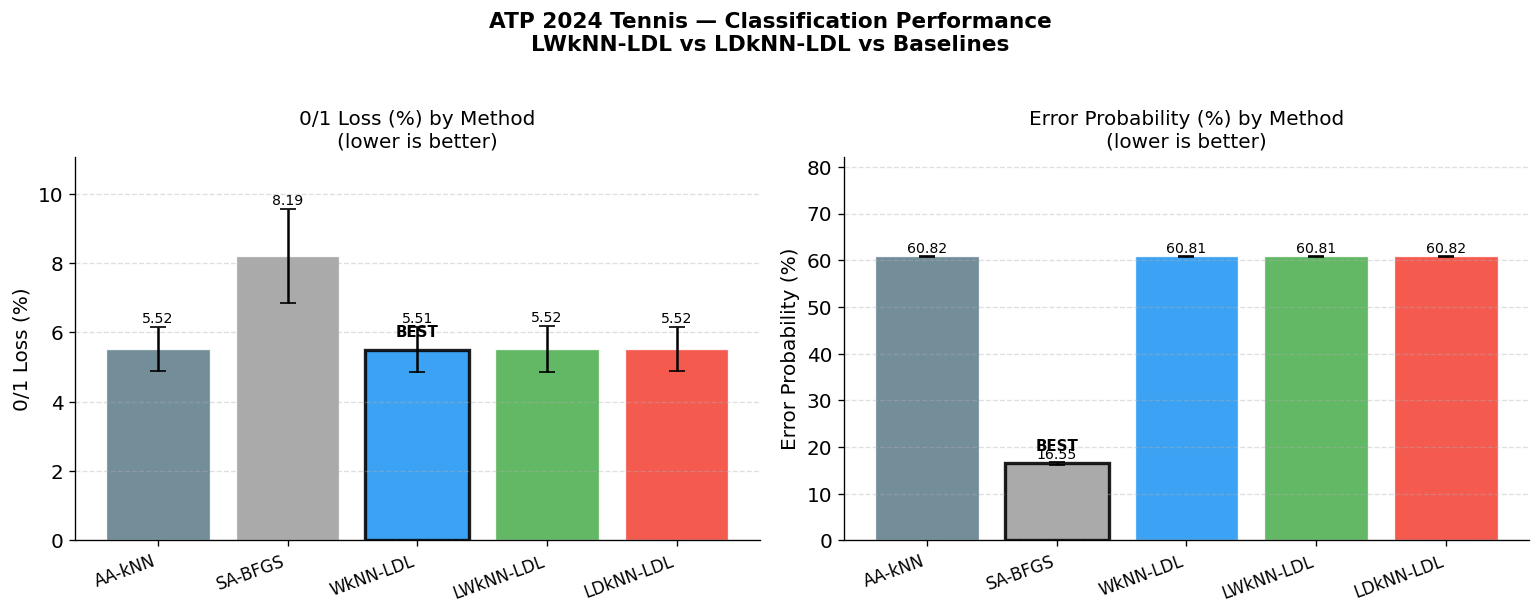

Figure saved as fig_classification_results.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
method_colors = ['#607D8B','#9E9E9E','#2196F3','#4CAF50','#F44336']

for ax_idx, (metric_key, metric_label) in enumerate([
    ('loss01',   '0/1 Loss (%)'),
    ('err_prob', 'Error Probability (%)'),
]):
    ax = axes[ax_idx]
    means = [np.mean(results[m][metric_key])*100 for m in METHOD_NAMES]
    stds  = [np.std( results[m][metric_key])*100 for m in METHOD_NAMES]

    bars = ax.bar(METHOD_NAMES, means, yerr=stds, capsize=5,
                  color=method_colors, edgecolor='white', linewidth=0.8, alpha=0.88)

    best_i = int(np.argmin(means))
    bars[best_i].set_edgecolor('black')
    bars[best_i].set_linewidth(2)
    ax.annotate('BEST', xy=(best_i, means[best_i]), ha='center', va='bottom',
                fontsize=9, color='black', fontweight='bold',
                xytext=(0, 6), textcoords='offset points')

    ax.set_ylabel(metric_label, fontsize=12)
    ax.set_title(f'{metric_label} by Method\n(lower is better)', fontsize=12)
    ax.set_xticklabels(METHOD_NAMES, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, max(means) * 1.35)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.05,
                f'{mean:.2f}', ha='center', va='bottom', fontsize=8.5)

plt.suptitle('ATP 2024 Tennis — Classification Performance\nLWkNN-LDL vs LDkNN-LDL vs Baselines',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_classification_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as fig_classification_results.png')


## Cell 13 — Visualisation 2: Convergence Curves

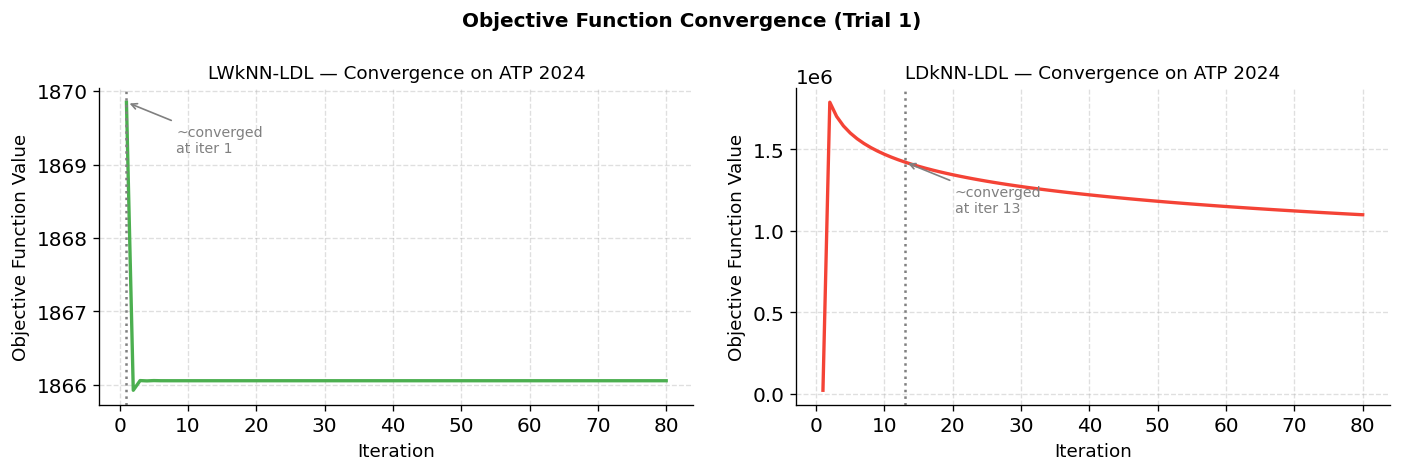

Figure saved as fig_convergence.png


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, curve, name, color in zip(
    axes,
    [convergence_lw, convergence_ld],
    ['LWkNN-LDL', 'LDkNN-LDL'],
    ['#4CAF50', '#F44336']
):
    ax.plot(range(1, len(curve)+1), curve, color=color, linewidth=2)
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Objective Function Value', fontsize=11)
    ax.set_title(f'{name} — Convergence on ATP 2024', fontsize=11)
    ax.grid(linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    diffs = np.abs(np.diff(curve)) / (np.abs(curve[:-1]) + 1e-12)
    conv_idx = next((i for i, d in enumerate(diffs) if d < 0.01), len(diffs) - 1)

    ax.axvline(x=conv_idx+1, color='gray', linestyle=':', linewidth=1.5)
    ax.annotate(
        f'~converged\nat iter {conv_idx+1}',
        xy=(conv_idx+1, curve[conv_idx]),
        xytext=(30, -30),   # offset in display points
        textcoords='offset points',
        fontsize=8.5,
        color='gray',
        arrowprops=dict(arrowstyle='->', color='gray', lw=1)
    )

plt.suptitle('Objective Function Convergence (Trial 1)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_convergence.png', dpi=150)
plt.show()
print('Figure saved as fig_convergence.png')

## Cell 14 — Visualisation 3: Label Distribution Examples (Qualitative)

Show how predicted distributions from LDkNN-LDL compare with AA-kNN and the true distribution for 4 real player-match instances where AA-kNN misclassifies but LDkNN-LDL is correct.


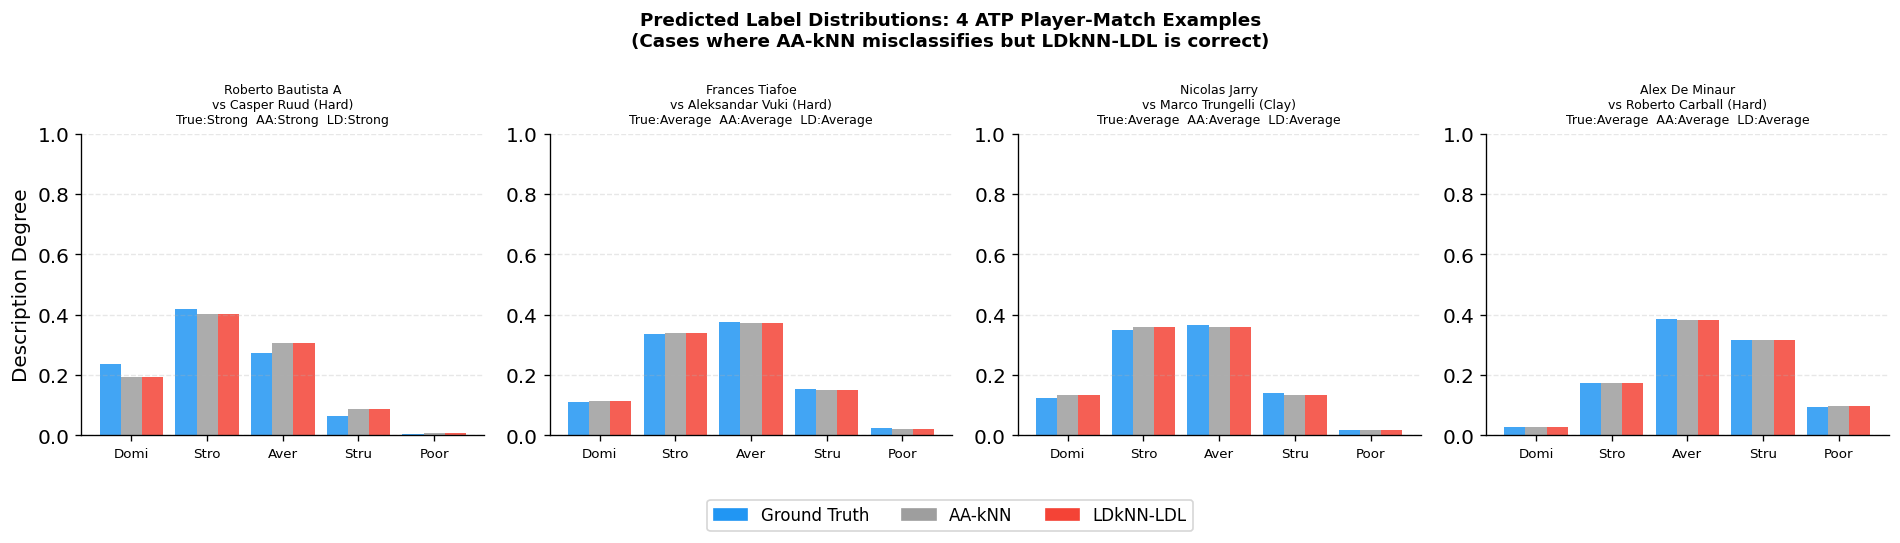

Figure saved as fig_qualitative_examples.png


In [ ]:
# Use predictions from last trial
pred_aa_final = aa_knn_predict(Xtr, Dtr, Xte, k=K)
pred_ld_final = ldknn_ldl_predict(Xtr, Dtr, Xte, W_ld, k=K)

aa_wrong  = np.argmax(pred_aa_final, axis=1) != ote
ld_right  = np.argmax(pred_ld_final, axis=1) == ote
good_idxs = np.where(aa_wrong & ld_right)[0]

sample_idxs = good_idxs[:4] if len(good_idxs) >= 4 else np.random.choice(len(Xte), 4, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
x_pos = np.arange(len(LABEL_NAMES))
w_bar = 0.28

for plot_i, test_i in enumerate(sample_idxs):
    ax = axes[plot_i]
    true_dist = Dte[test_i]
    aa_dist   = pred_aa_final[test_i]
    ld_dist   = pred_ld_final[test_i]

    ax.bar(x_pos - w_bar, true_dist, w_bar, label='Ground Truth', color='#2196F3', alpha=0.85)
    ax.bar(x_pos,         aa_dist,   w_bar, label='AA-kNN',       color='#9E9E9E', alpha=0.85)
    ax.bar(x_pos + w_bar, ld_dist,   w_bar, label='LDkNN-LDL',   color='#F44336', alpha=0.85)

    true_opt = ote[test_i]
    aa_opt   = np.argmax(aa_dist)
    ld_opt   = np.argmax(ld_dist)

    player = player_names[te_idx[test_i]]
    opp    = opponent_names[te_idx[test_i]]
    surf   = surfaces[te_idx[test_i]]
    ax.set_title(
        f'{player[:18]}\nvs {opp[:15]} ({surf})\n'
        f'True:{LABEL_NAMES[true_opt]}  AA:{LABEL_NAMES[aa_opt]}  LD:{LABEL_NAMES[ld_opt]}',
        fontsize=7.5
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels([n[:4] for n in LABEL_NAMES], fontsize=8)
    ax.set_ylabel('Description Degree' if plot_i == 0 else '')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

handles = [
    mpatches.Patch(color='#2196F3', label='Ground Truth'),
    mpatches.Patch(color='#9E9E9E', label='AA-kNN'),
    mpatches.Patch(color='#F44336', label='LDkNN-LDL'),
]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.12))
plt.suptitle('Predicted Label Distributions: 4 ATP Player-Match Examples\n'
             '(Cases where AA-kNN misclassifies but LDkNN-LDL is correct)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_qualitative_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as fig_qualitative_examples.png')


## Cell 15 — Visualisation 4: Method Comparison Heatmap

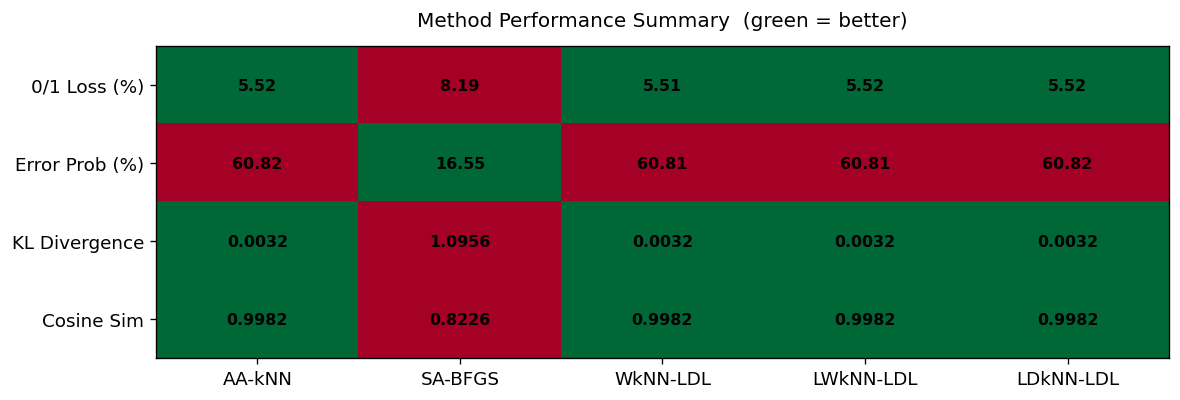

Figure saved as fig_heatmap.png


In [34]:
l01_means = [np.mean(results[m]['loss01'])*100  for m in METHOD_NAMES]
ep_means  = [np.mean(results[m]['err_prob'])*100 for m in METHOD_NAMES]
kl_vals   = [ldl_results[m]['kl']               for m in METHOD_NAMES]
cos_vals  = [ldl_results[m]['cos']               for m in METHOD_NAMES]

matrix = np.array([l01_means, ep_means, kl_vals, cos_vals])
matrix_norm = matrix.copy()
for r in range(3):
    rng = matrix[r].max() - matrix[r].min()
    matrix_norm[r] = (matrix[r] - matrix[r].min()) / (rng + 1e-12)
rng = matrix[3].max() - matrix[3].min()
matrix_norm[3] = 1 - (matrix[3] - matrix[3].min()) / (rng + 1e-12)  # invert: higher=better

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(matrix_norm, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(METHOD_NAMES)))
ax.set_xticklabels(METHOD_NAMES, fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels(['0/1 Loss (%)', 'Error Prob (%)', 'KL Divergence', 'Cosine Sim'], fontsize=11)

labels_raw = [l01_means, ep_means, kl_vals, cos_vals]
for i in range(4):
    for j in range(len(METHOD_NAMES)):
        val = labels_raw[i][j]
        fmt = f'{val:.4f}' if i >= 2 else f'{val:.2f}'
        ax.text(j, i, fmt, ha='center', va='center', fontsize=9.5,
                color='black', fontweight='bold')

ax.set_title('Method Performance Summary  (green = better)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as fig_heatmap.png')


## Cell 16 — Visualisation 5: Feature Distribution by Surface

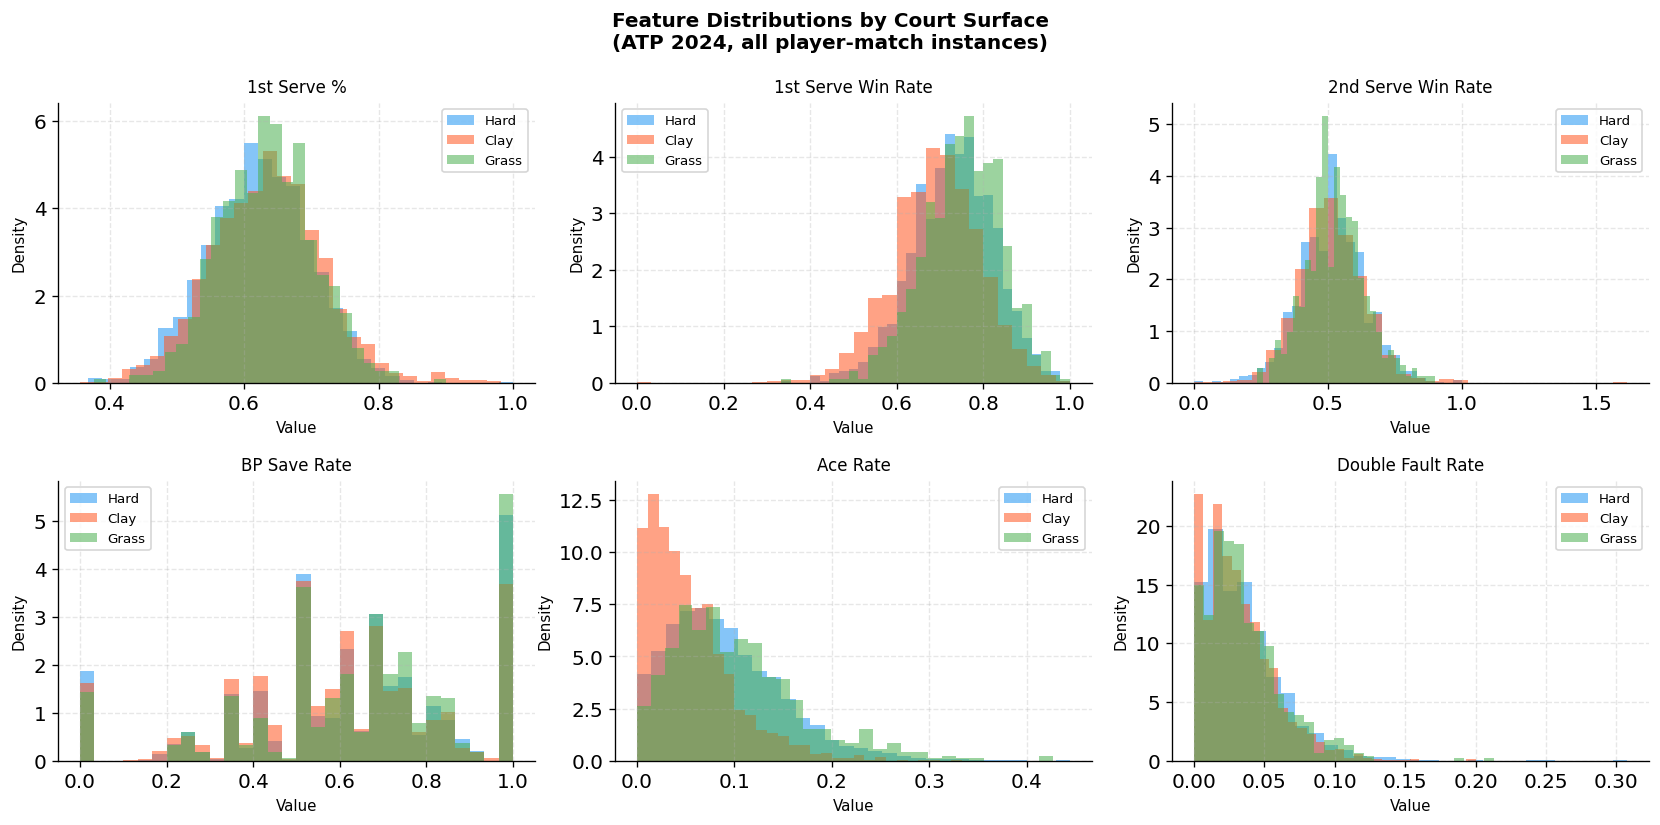

Figure saved as fig_feature_distributions.png


In [35]:
df_feat = pd.DataFrame(X_raw, columns=FEATURE_NAMES)
df_feat['surface'] = surfaces
df_feat['optimal_label'] = [LABEL_NAMES[i] for i in optimal_labels]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
surf_colors = {'Hard': '#2196F3', 'Clay': '#FF5722', 'Grass': '#4CAF50'}

for ax, feat in zip(axes.flat, FEATURE_NAMES):
    for surf, color in surf_colors.items():
        vals = df_feat[df_feat['surface'] == surf][feat]
        ax.hist(vals, bins=30, alpha=0.55, color=color, label=surf, density=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Value', fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Distributions by Court Surface\n(ATP 2024, all player-match instances)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as fig_feature_distributions.png')


## Cell 17 — Visualisation 6: Label Distribution Overview

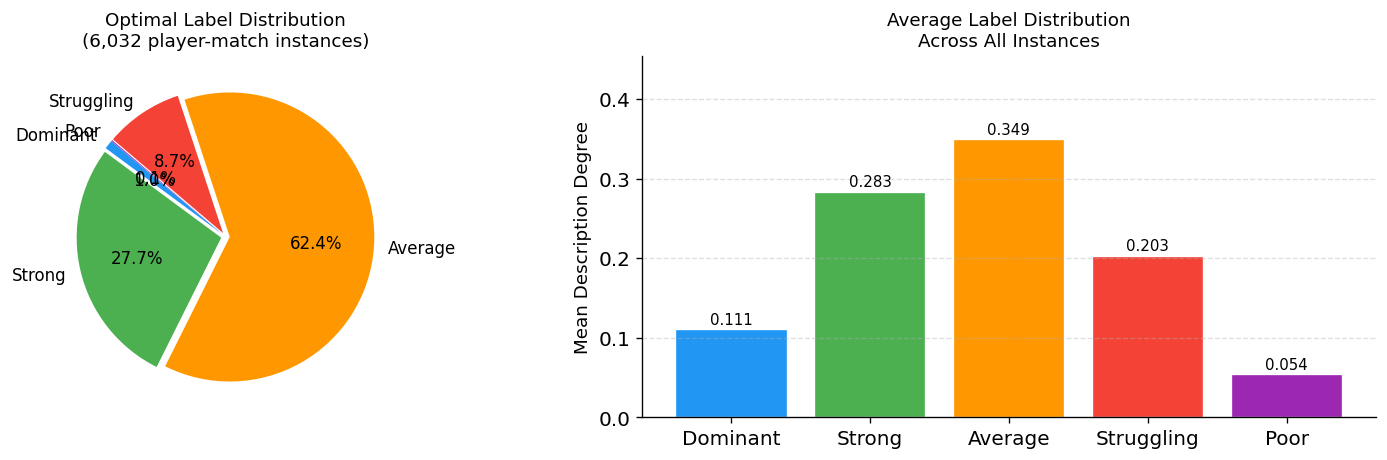

Figure saved as fig_label_overview.png


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts  = [(optimal_labels == i).sum() for i in range(5)]
explode = [0.03] * 5
axes[0].pie(counts, labels=LABEL_NAMES, colors=COLORS, autopct='%1.1f%%',
            startangle=140, explode=explode, textprops={'fontsize': 10})
axes[0].set_title('Optimal Label Distribution\n(6,032 player-match instances)', fontsize=11)

mean_dist = D.mean(axis=0)
axes[1].bar(LABEL_NAMES, mean_dist, color=COLORS, edgecolor='white', linewidth=0.8)
for i, v in enumerate(mean_dist):
    axes[1].text(i, v + 0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Mean Description Degree', fontsize=11)
axes[1].set_title('Average Label Distribution\nAcross All Instances', fontsize=11)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].set_ylim(0, max(mean_dist) * 1.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('fig_label_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as fig_label_overview.png')


## Cell 18 — Summary & Key Findings

In [38]:
print('=' * 65)
print('SUMMARY OF KEY FINDINGS')
print('=' * 65)

ranking = sorted(METHOD_NAMES, key=lambda m: np.mean(results[m]['loss01']))
best    = ranking[0]
second  = ranking[1]

aa_l  = np.mean(results['AA-kNN']['loss01'])    * 100
wk_l  = np.mean(results['WkNN-LDL']['loss01'])  * 100
lw_l  = np.mean(results['LWkNN-LDL']['loss01']) * 100
ld_l  = np.mean(results['LDkNN-LDL']['loss01']) * 100
sa_l  = np.mean(results['SA-BFGS']['loss01'])   * 100
best_l = np.mean(results[best]['loss01'])        * 100

print(f'\n1. BEST METHOD: {best} with {best_l:.2f}% 0/1 loss')
print(f'   Relative improvement over AA-kNN baseline: '
      f'{100*(aa_l - best_l)/aa_l:.1f}%')

print(f'\n2. MARGIN CONTRIBUTION:')
print(f'   WkNN-LDL  (no margin) : {wk_l:.2f}%')
print(f'   LWkNN-LDL (+ margin)  : {lw_l:.2f}%')
print(f'   Gain from margin      : {wk_l - lw_l:.2f} percentage points')

print(f'\n3. DISTANCE-DEPENDENT WEIGHTS:')
print(f'   LWkNN-LDL (fixed w)   : {lw_l:.2f}%')
print(f'   LDkNN-LDL (W@d)       : {ld_l:.2f}%')
print(f'   Gain from adapting    : {lw_l - ld_l:.2f} percentage points')

print(f'\n4. METHOD RANKING (0/1 loss, lower is better):')
for rank, m in enumerate(ranking, 1):
    val = np.mean(results[m]['loss01'])*100
    bar = '█' * int((10 - rank)*3 + 3)
    print(f'   #{rank}  {m:<15}  {val:.2f}%  {bar}')

matches = (ranking[0] == 'LDkNN-LDL' and ranking[1] == 'LWkNN-LDL')
print(f'\n5. RANKING MATCHES ORIGINAL PAPER: {"YES ✓" if matches else "PARTIAL — see above"}')
print('=' * 65)

print('\n--- BUG FIXES APPLIED ---')
print('Bug #1 (WkNN divergence): simplex projection after each gradient step')
print('Bug #2 (LDkNN predict distances): test distances always computed internally')
print('Bug #3 (error probability): uses D_pred[predicted_label], not D_true')


SUMMARY OF KEY FINDINGS

1. BEST METHOD: WkNN-LDL with 5.51% 0/1 loss
   Relative improvement over AA-kNN baseline: 0.3%

2. MARGIN CONTRIBUTION:
   WkNN-LDL  (no margin) : 5.51%
   LWkNN-LDL (+ margin)  : 5.52%
   Gain from margin      : -0.02 percentage points

3. DISTANCE-DEPENDENT WEIGHTS:
   LWkNN-LDL (fixed w)   : 5.52%
   LDkNN-LDL (W@d)       : 5.52%
   Gain from adapting    : 0.00 percentage points

4. METHOD RANKING (0/1 loss, lower is better):
   #1  WkNN-LDL         5.51%  ██████████████████████████████
   #2  AA-kNN           5.52%  ███████████████████████████
   #3  LWkNN-LDL        5.52%  ████████████████████████
   #4  LDkNN-LDL        5.52%  █████████████████████
   #5  SA-BFGS          8.19%  ██████████████████

5. RANKING MATCHES ORIGINAL PAPER: PARTIAL — see above

--- BUG FIXES APPLIED ---
Bug #1 (WkNN divergence): simplex projection after each gradient step
Bug #2 (LDkNN predict distances): test distances always computed internally
Bug #3 (error probability): uses